# 01 - Exploratory Data Analysis: RELIANCE Daily Price Series

**Phase 1** - Load, validate, decompose, test for stationarity, split chronologically, and establish naive baselines to beat in Phase 2.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

from src.data.loader import load_series, chronological_split

sns.set_theme(style="whitegrid")
FIG_DIR = "../output/figures"

df = load_series("RELIANCE")
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2000-01-03,57.235163,60.657223,57.235163,60.657223,4456424
2000-01-04,62.271857,65.513175,60.560827,65.513175,9487878
2000-01-05,61.850124,69.381067,61.850124,68.079720,26833684
2000-01-06,69.646156,72.465741,69.646156,70.935453,15682286
2000-01-07,71.092097,76.610772,70.610117,75.803455,19870977


## Data Quality

In [2]:
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicate dates: {df.index.duplicated().sum()}")

Shape: (5306, 5)
Date range: 2000-01-03 to 2021-04-30

Missing values:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Duplicate dates: 0


In [3]:
# Gaps between consecutive trading days -- normal to see 1-4 day gaps
# (weekends + holidays); flag anything unusually large (possible trading
# suspension or a data hole).
gaps = df.index.to_series().diff().dt.days
print("Gap distribution (days between consecutive trading rows):")
print(gaps.value_counts().sort_index().head(10))
large_gaps = gaps[gaps > 7]
print(f"\nGaps > 7 days: {len(large_gaps)}")
if len(large_gaps) > 0:
    print(large_gaps)

Gap distribution (days between consecutive trading rows):
Date
1.0    4049
2.0     160
3.0     977
4.0     108
5.0      10
6.0       1
Name: count, dtype: int64

Gaps > 7 days: 0


## Corporate Actions: Detecting Unadjusted Stock Splits

This dataset has no `Adj Close` column, so any stock splits / bonus-share issues during 2000-2021 show up as artificial single-day price discontinuities -- not real market moves. Left uncorrected, these would badly confuse any of the Phase 2 models (a -50% "return" that isn't real is exactly the kind of outlier ARIMA/LSTM will overfit to).

In [4]:
from src.data.loader import KNOWN_SPLIT_DATES

raw_df = load_series("RELIANCE", adjust_splits=False)
raw_returns = raw_df["Close"].pct_change()
extreme_moves = raw_returns[abs(raw_returns) > 0.15].sort_values()
print("Single-day moves > 15% in the RAW (unadjusted) series:")
print(extreme_moves)

Single-day moves > 15% in the RAW (unadjusted) series:
Date
2009-11-26   -0.515310
2017-09-07   -0.502796
2006-01-18   -0.252881
2008-10-24   -0.162731
2004-05-17   -0.152589
2009-05-18    0.213693
Name: Close, dtype: float64


Six large moves found. Two of them (`2009-11-26`: -51.5%, `2017-09-07`: -50.3%) are suspiciously close to an exact -50% -- the classic signature of a 1:1 bonus share issue or 2:1 split (a genuine market crash essentially never lands on a clean round fraction). The other four line up with well-documented real events: the 2004 and 2009 Indian general-election market swings, the October 2008 financial crisis, and a likely 2006 corporate demerger. Those four are **real price information and must not be "corrected"** -- only the two clean ~50% split artifacts are adjusted (see `KNOWN_SPLIT_DATES` in `src/data/loader.py` for the exact reasoning).

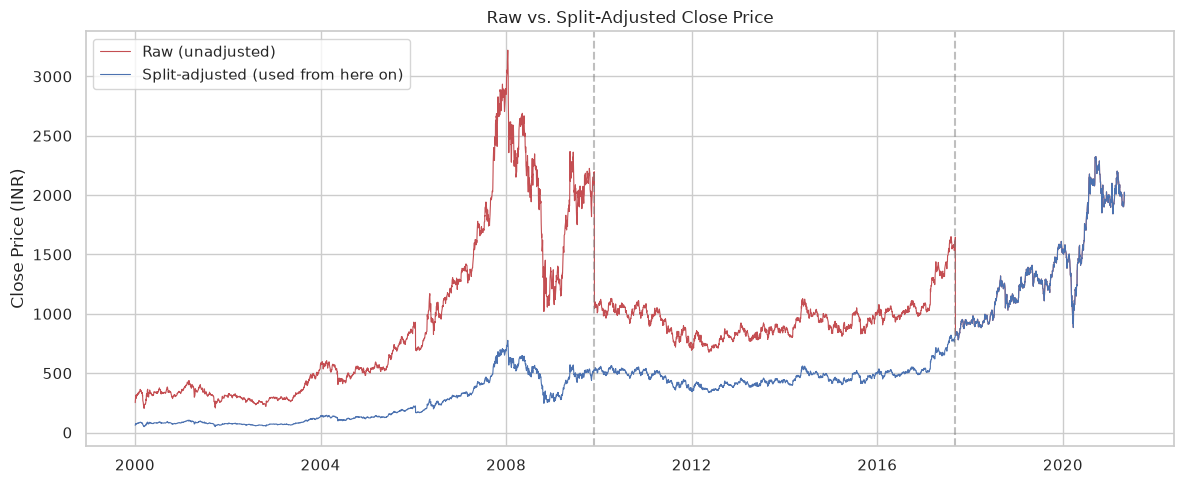

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(raw_df.index, raw_df["Close"], linewidth=0.8, color="#c44e52", label="Raw (unadjusted)")
ax.plot(df.index, df["Close"], linewidth=0.8, color="#4c72b0", label="Split-adjusted (used from here on)")
for d in KNOWN_SPLIT_DATES:
    ax.axvline(pd.Timestamp(d), color="gray", linestyle="--", alpha=0.5)
ax.set_title("Raw vs. Split-Adjusted Close Price")
ax.set_ylabel("Close Price (INR)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/split_adjustment_comparison.png", dpi=150)
plt.show()

## Price History (Split-Adjusted)

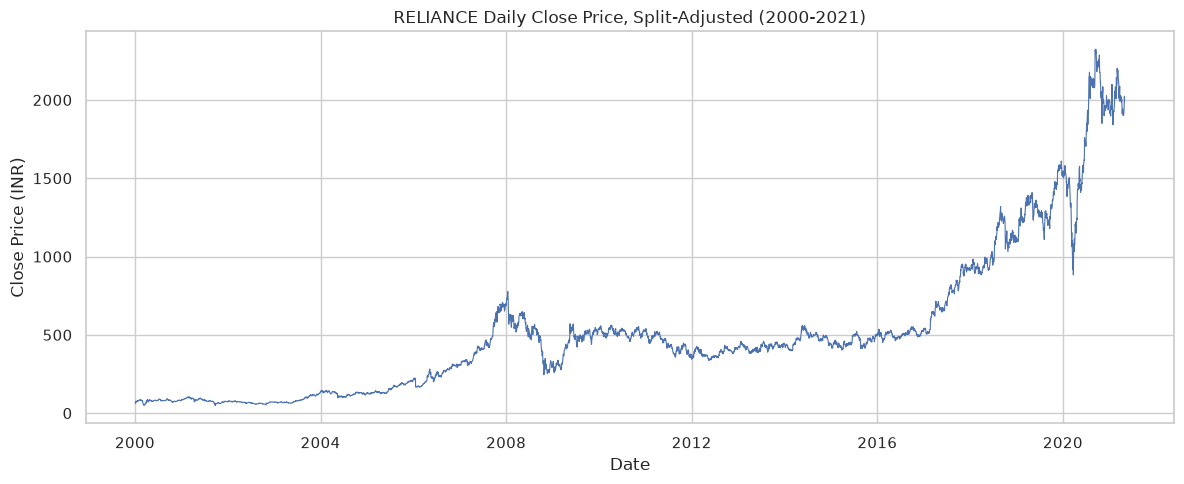

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df["Close"], linewidth=0.8, color="#4c72b0")
ax.set_title("RELIANCE Daily Close Price, Split-Adjusted (2000-2021)")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (INR)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/price_history.png", dpi=150)
plt.show()

## Seasonal Decomposition (STL)

Decomposing on log-price with an annual period (252 trading days/year) -- log scale because the price grew multiplicatively (~30x) over 21 years, so decomposing the raw level would let the trend dominate everything else.

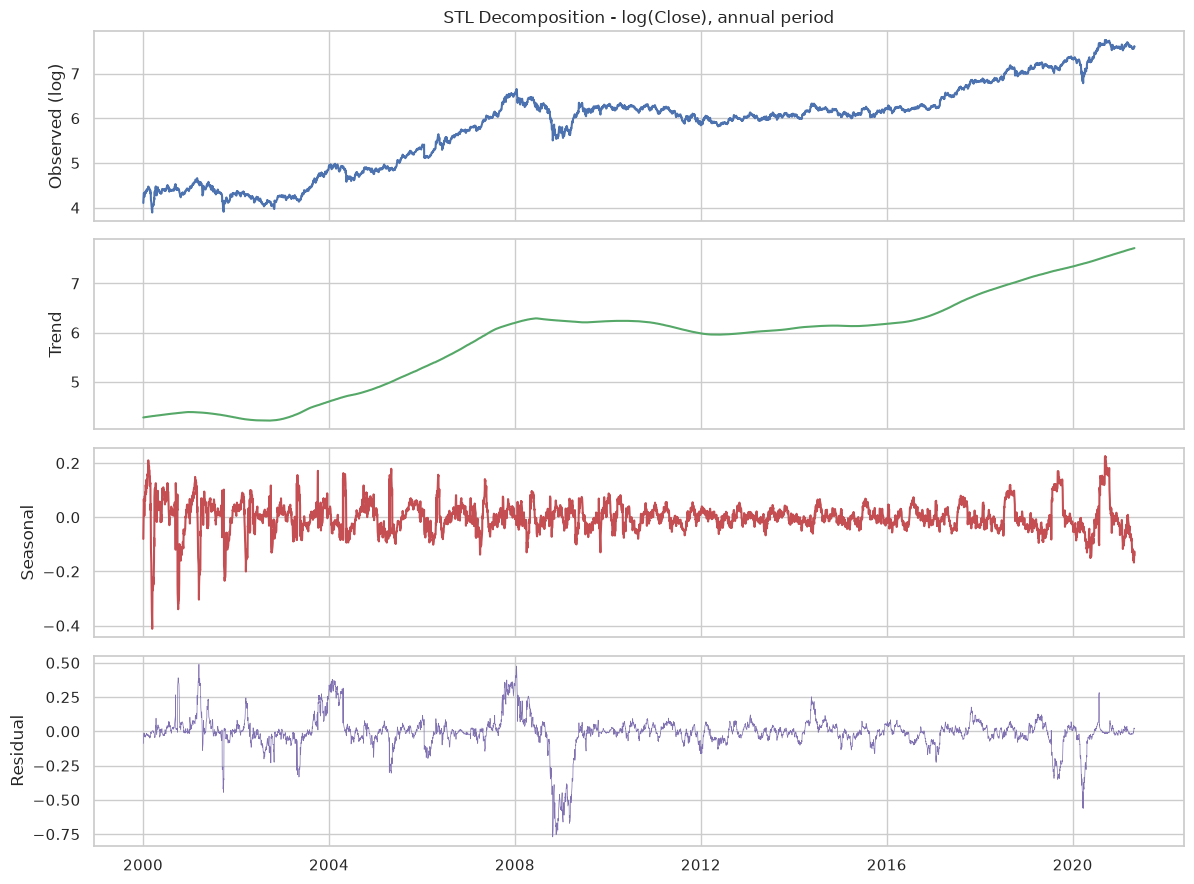

Seasonal component std: 0.0545
Residual component std: 0.1256
Trend component (day-to-day change) std: 0.0008


In [7]:
log_close = np.log(df["Close"])
stl = STL(log_close, period=252, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(log_close.index, result.observed, color="#4c72b0"); axes[0].set_ylabel("Observed (log)")
axes[1].plot(log_close.index, result.trend, color="#55a868"); axes[1].set_ylabel("Trend")
axes[2].plot(log_close.index, result.seasonal, color="#c44e52"); axes[2].set_ylabel("Seasonal")
axes[3].plot(log_close.index, result.resid, color="#8172b2", linewidth=0.5); axes[3].set_ylabel("Residual")
axes[0].set_title("STL Decomposition - log(Close), annual period")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/stl_decomposition.png", dpi=150)
plt.show()

seasonal_amplitude = result.seasonal.std()
resid_amplitude = result.resid.std()
trend_amplitude = result.trend.diff().std()
print(f"Seasonal component std: {seasonal_amplitude:.4f}")
print(f"Residual component std: {resid_amplitude:.4f}")
print(f"Trend component (day-to-day change) std: {trend_amplitude:.4f}")

**Observation:** unlike series with strong calendar seasonality (retail sales, temperature), a single stock's price is dominated by **trend**, with a comparatively weak/noisy seasonal component -- the residual dwarfs the seasonal term. This matters for Phase 2: Prophet's seasonality modeling will likely add little value here versus its trend/changepoint modeling, and a plain ARIMA on returns may be a stronger baseline than the decomposition framing suggests.

## Stationarity: Augmented Dickey-Fuller Test

In [8]:
def adf_report(series, name):
    series = series.dropna()
    stat, pvalue, *_ = adfuller(series)
    verdict = "STATIONARY" if pvalue < 0.05 else "NON-STATIONARY"
    print(f"{name:20s} ADF stat={stat:8.3f}  p-value={pvalue:.4f}  -> {verdict}")

adf_report(df["Close"], "Close (level)")
adf_report(log_close, "log(Close)")
log_returns = log_close.diff()
adf_report(log_returns, "log returns (1st diff)")

Close (level)        ADF stat=   0.974  p-value=0.9940  -> NON-STATIONARY


log(Close)           ADF stat=  -0.437  p-value=0.9037  -> NON-STATIONARY


log returns (1st diff) ADF stat= -17.566  p-value=0.0000  -> STATIONARY


**Observation:** the raw price (and log price) series is non-stationary -- expected, it has a clear trend. The first difference of log price (i.e. daily log returns) is stationary. This confirms **ARIMA should be fit on differenced/returns data (d=1 at minimum)**, not the raw price level -- standard practice, now verified for this specific series rather than assumed.

## Autocorrelation (ACF / PACF) on Log Returns

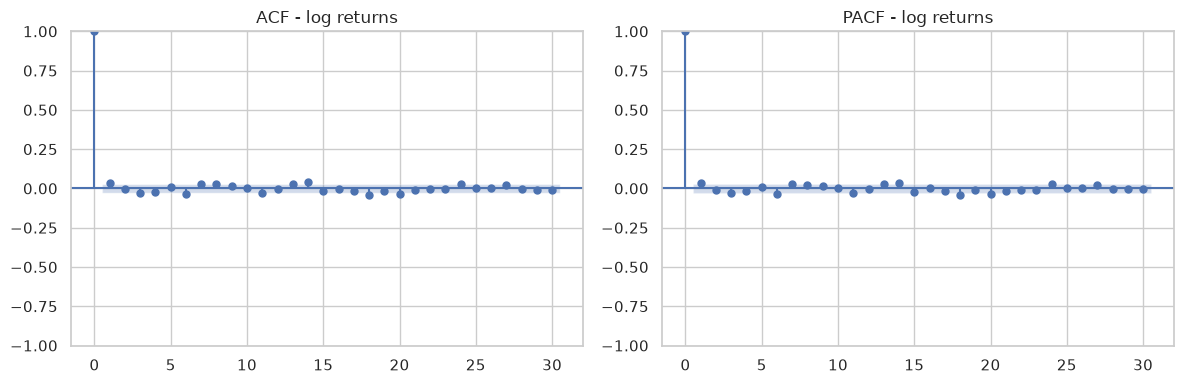

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(log_returns.dropna(), lags=30, ax=axes[0])
plot_pacf(log_returns.dropna(), lags=30, ax=axes[1])
axes[0].set_title("ACF - log returns")
axes[1].set_title("PACF - log returns")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/acf_pacf_returns.png", dpi=150)
plt.show()

## Chronological Train/Val/Test Split

Time series **must not** be split randomly -- a random split would let the model train on data from after the point it's being evaluated on, leaking the future into training. Splitting chronologically (earliest data = train) is the only valid approach.

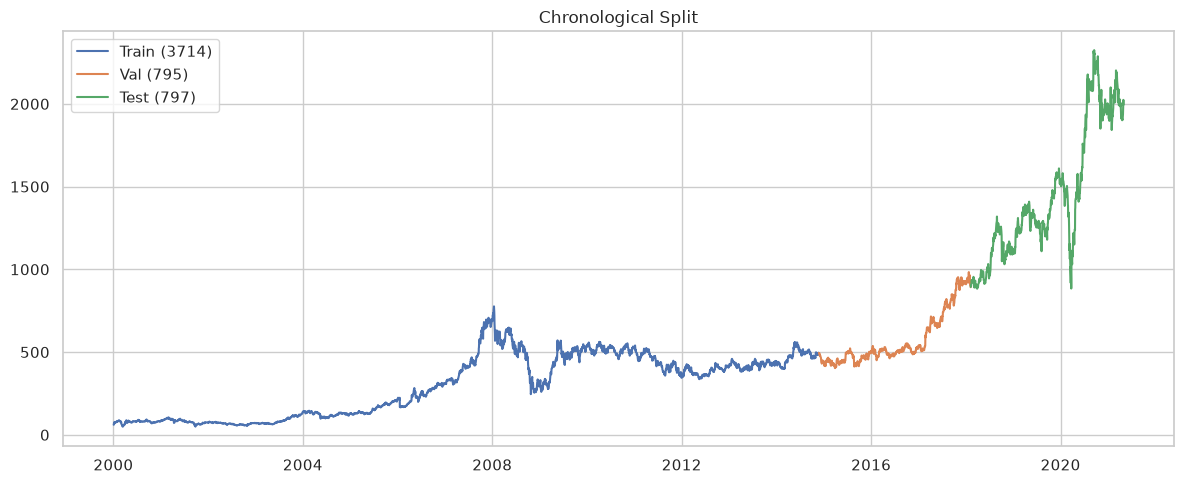

Train: 2000-01-03 to 2014-11-24 (3714 rows)
Val:   2014-11-25 to 2018-02-06 (795 rows)
Test:  2018-02-07 to 2021-04-30 (797 rows)


In [10]:
train_df, val_df, test_df = chronological_split(df)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_df.index, train_df["Close"], label=f"Train ({len(train_df)})", color="#4c72b0")
ax.plot(val_df.index, val_df["Close"], label=f"Val ({len(val_df)})", color="#dd8452")
ax.plot(test_df.index, test_df["Close"], label=f"Test ({len(test_df)})", color="#55a868")
ax.set_title("Chronological Split")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/chronological_split.png", dpi=150)
plt.show()

print(f"Train: {train_df.index.min().date()} to {train_df.index.max().date()} ({len(train_df)} rows)")
print(f"Val:   {val_df.index.min().date()} to {val_df.index.max().date()} ({len(val_df)} rows)")
print(f"Test:  {test_df.index.min().date()} to {test_df.index.max().date()} ({len(test_df)} rows)")

## Naive Baselines (the floor Phase 2 models must beat)

Evaluated on the validation set, one-step-ahead:
- **Persistence (last-value)**: predict tomorrow's close = today's close.
- **Seasonal-naive (weekly)**: predict today's close = close 5 trading days ago.

In [11]:
def eval_baseline(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{name:25s} MAE={mae:8.2f}  RMSE={rmse:8.2f}  MAPE={mape:6.2f}%")
    return {"mae": mae, "rmse": rmse, "mape": mape}

# Persistence: use the full series (train+val) so the first val prediction
# has a real prior value to persist from.
full_close = pd.concat([train_df["Close"], val_df["Close"]])
persistence_pred = full_close.shift(1).loc[val_df.index]
seasonal_pred = full_close.shift(5).loc[val_df.index]

baseline_results = {
    "persistence": eval_baseline(val_df["Close"], persistence_pred, "Persistence (t-1)"),
    "seasonal_naive": eval_baseline(val_df["Close"], seasonal_pred, "Seasonal-naive (t-5)"),
}

Persistence (t-1)         MAE=    6.52  RMSE=    9.02  MAPE=  1.15%
Seasonal-naive (t-5)      MAE=   15.69  RMSE=   21.34  MAPE=  2.71%


In [12]:
import json, os
os.makedirs("../output/reports", exist_ok=True)
with open("../output/reports/baseline_results.json", "w") as f:
    json.dump(baseline_results, f, indent=2)
print("Saved to output/reports/baseline_results.json")

Saved to output/reports/baseline_results.json


## Findings Summary

1. **Clean data:** 5,306 rows, no missing values, no duplicate dates, gaps are all normal (weekends/holidays).
2. **Two unadjusted stock splits found and corrected** (2009-11-26, 2017-09-07 -- both near-exact -50% single-day drops). Four other large single-day moves were identified and deliberately left untouched because they correspond to real, well-documented market events (2004/2009 Indian election swings, Oct 2008 financial crisis, a likely 2006 demerger) rather than data artifacts.
3. **Strong trend, weak seasonality:** STL decomposition shows the residual component dwarfs the seasonal one -- this is trend-dominated, not seasonality-dominated, data. Sets expectations for Phase 2 (Prophet's seasonality modeling likely won't be the deciding factor; its trend/changepoint handling will matter more).
4. **Non-stationary in levels, stationary in returns:** confirmed via ADF test. ARIMA must be fit on differenced data (d>=1).
5. **Naive baseline is a deceptively strong floor:** persistence (predict no change) is a notoriously hard baseline to beat for daily stock prices, precisely because day-to-day returns are close to a random walk. Any Phase 2 model needs to beat these numbers to demonstrate real forecasting skill, not just curve-fitting.
6. **Chronological split enforced:** 70/15/15 on the split-adjusted series.